---
title: "Lab 5.1: Dimensionality reduction with Auto-encoders"
author: "Jorge Bris Moreno"
format:
    html:
        embed-resources: true
        code-fold: true
        toc: true
        before_body: scripts.html
---

# Lab: 
Dimensionality reduction with Auto-encoders

## Overview 

* In this lab we will be working with fashion_mnist, so that the code will run quickly on our laptops.
* However, the concepts can be easily generalized and applied to any data-set. 
  
**Submission:**
* You need to upload ONE document to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of this notebook 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

## Import 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import models
from keras import layers
import keras
from keras.utils import to_categorical
from keras.datasets import fashion_mnist
from keras.callbacks import EarlyStopping
from mpl_toolkits.mplot3d import Axes3D

2024-05-01 12:28:03.706058: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Part-1: Load data

* Load the fashion_mnist data 
* Read the additional assignment tasks below and normalize and reshape the data as needed
* **Optional**: randomly visualize a couple of images 

Shapes: 
----------------------------------
Train images:  (60000, 28, 28) 
Shape of train labels:  (60000,) 
Shape of test images:  (10000, 28, 28) 
Shape of test labels:  (10000,)


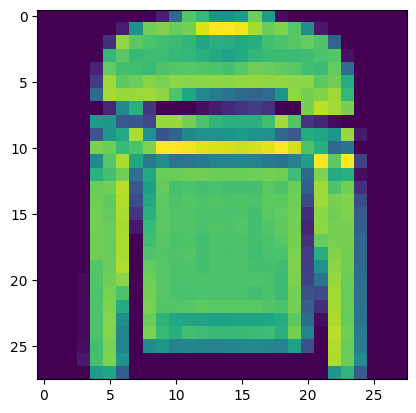

In [2]:
# INSERT CODE HERE
# fashion mnist dataset
(train_im, train_labels), (test_im, test_labels) = fashion_mnist.load_data()

# Print shapes
print("Shapes:", "\n----------------------------------")
print("Train images: ", train_im.shape, "\nShape of train labels: ", train_labels.shape, "\nShape of test images: ", test_im.shape, "\nShape of test labels: ", test_labels.shape)

# normalize pixel values
train_im = train_im.astype('float32') / 255
test_im = test_im.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Plot and image
plt.imshow(train_im[5])

## Part-2: Auto-encoder training 

* Write a function that;
  * Takes a bottle-neck size as an input and returns training/validation errors for the auto-encoder
  * Your training function MUST include an early stopping call-back to avoid over-fitting
  * Do this with a standard dense feed forward auto-encoder with one hidden layer (i.e. not VAE) 
    * **Optional**: If you want you can use a convolutional auto-encoder instead of a dense feed forward ANN 
  * **NOTE**: You can do this with Keras or Pytorch, however, Keras is recommended since you can recycle large portions of the lecture-codes.

In [3]:
# INSERT CODE HERE

# dense autoencoder
def autoencoderinator(size_b_neck):

    model = models.Sequential([
        layers.Dense(size_b_neck, activation='linear', input_shape=(28 * 28,)),
        layers.Dense(28 * 28, activation='linear')
    ])
    return model

# training function
def training_autoencoder_mod(size_b_neck):
    
    global train_im

    model = autoencoderinator(size_b_neck)
    
    # compile model
    model.compile(optimizer='rmsprop', loss='mean_squared_error')

    # early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5)

    # reshape training images for model
    x_train = train_im.reshape((60000, 28 * 28))

    # training model
    history = model.fit(x_train, x_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

    # return training and validation loss per epoch
    return history.history['loss'], history.history['val_loss']

## Part-3: Find optimal latent space size 

* Wrap a grid search loop (or random search) around your training function from part-5.1.2 
* This search should try different bottle-neck sizes (latent space dimensionalities) 
* When the loop is done
  * Plot validation_loss vs latent_space_dimensionality
  * From the plot choose an "optimal" latent_space_dimension which has a good validation accuracy AND minimizes the size of the latent space

In [4]:
# INSERT CODE HERE

# grid search over bottleneck sizes fucntion
def grid_search(sizes_b_necks):

    # store validation losses (initially zeros)
    val_losses = np.zeros(len(sizes_b_necks))

    for i, size_b_neck in enumerate(sizes_b_necks):
        # train model for each bottleneck size
        _, val_loss = training_autoencoder_mod(size_b_neck)

        # save final validation loss
        val_losses[i] = val_loss[-1]

    return val_losses

# bottleneck sizes (grid)
sizes_b_necks = [4, 8, 16, 32, 64, 128, 256, 512]

# grid search
val_losses = grid_search(sizes_b_necks)

Epoch 1/100
375/375 [==============================] - 2s 4ms/step - loss: 0.0522 - val_loss: 0.0347
Epoch 2/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0310 - val_loss: 0.0292
Epoch 3/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0285 - val_loss: 0.0279
Epoch 4/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0276 - val_loss: 0.0273
Epoch 5/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0272 - val_loss: 0.0272
Epoch 6/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0271 - val_loss: 0.0271
Epoch 7/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0270 - val_loss: 0.0269
Epoch 8/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0269 - val_loss: 0.0269
Epoch 9/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0269 - val_loss: 0.0269
Epoch 10/100
375/375 [==============================] - 1s 2ms/step - loss: 0.0269 - val_lo

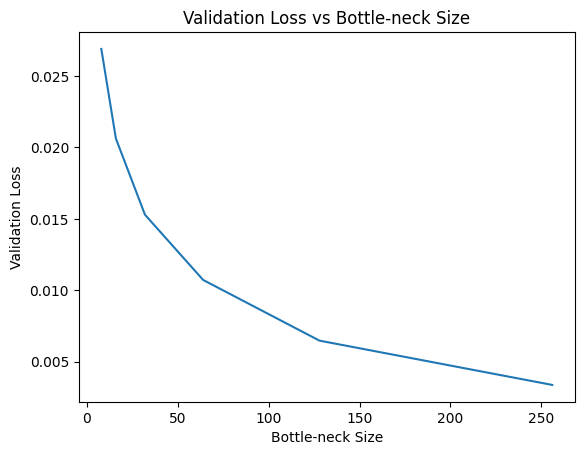

In [5]:
# Plot validation loss vs bottleneck size
plt.plot(sizes_b_necks, val_losses)
plt.title('Validation Loss vs Bottle-neck Size')
plt.xlabel('Bottle-neck Size')
plt.ylabel('Validation Loss')
plt.show()

This graph shows significant decrease in the validation loss as the latent space size increases. However, after 64, the decrease is not significant enough to increase the bottle neck size (as we do not want to overfit and it will also be more efficient). Therefore, we can choose 64 as the optimal latent space size.

## Part-4: Latent space visualization:

* Using your optimal latent space size;
  * Compute the latent space vector for each data point in the validation set (i.e. perform the dimensionality reduction)
  * Isolate the three latent space dimensions with the maximum variance
  * Plot the data in this latent space with color encoding representing the MNIST class values (0,1,2 .. )  

1875/1875 [==============================] - 2s 988us/step


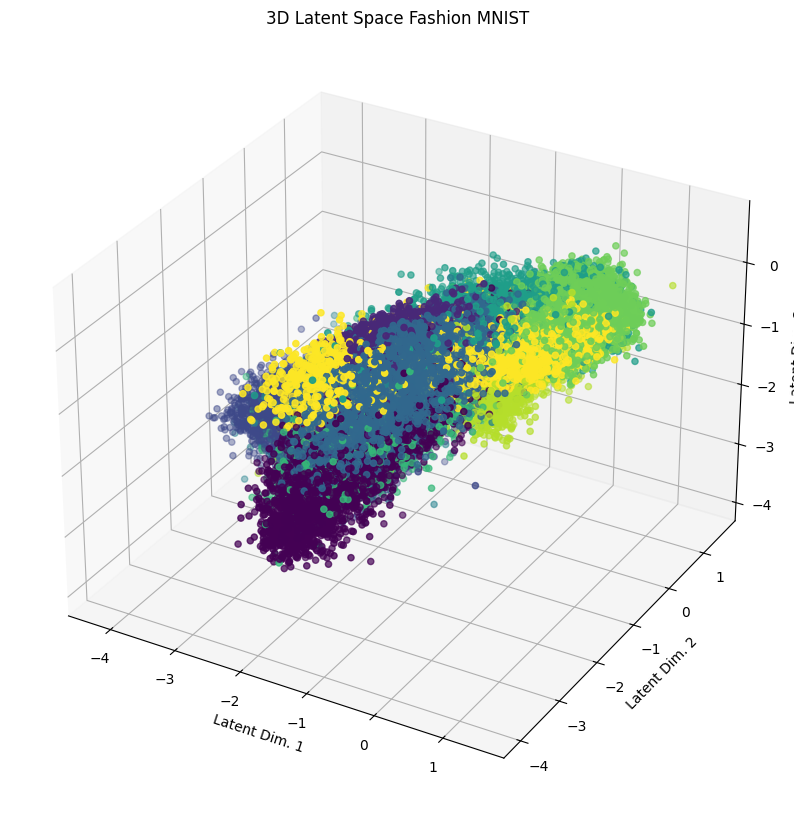

In [6]:
# INSERT CODE HERE

# 3D latent space of autoencoder's bottleneck feat.
def latent_space_plottinator(train_im, train_labels, bottleneck_size=8):

    # fit autoencoder and get bottleneck feat.
    model = autoencoderinator(bottleneck_size)
    model.compile(optimizer='rmsprop', loss='mean_squared_error')

    # reshape training images for model
    x_train = train_im.reshape((60000, 28 * 28))

    # train model
    model.fit(x_train, x_train, epochs=10, batch_size=1000, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=5)], verbose=0)

    # create model with output -- bottleneck feat.
    bottleneck_model = models.Model(inputs=model.input, outputs=model.layers[0].output)

    # predict feat.
    x_bottleneck = bottleneck_model.predict(x_train)

    # variances
    vars = np.var(x_bottleneck, axis=0)

    # top 3 indices (highest variances)
    top3_indices = np.argsort(vars)[::-1][:3]

    # subset data to top 3 indices
    x_bottleneck_top3 = x_bottleneck[:, top3_indices]

    # 3D scatter plot
    fig = plt.figure(figsize=(10, 12))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        xs=x_bottleneck_top3[:, 0], 
        ys=x_bottleneck_top3[:, 1], 
        zs=x_bottleneck_top3[:, 2], 
        c=train_labels.argmax(axis=1))

    # label axes and set title
    ax.set_title('3D Latent Space Fashion MNIST')
    ax.set_xlabel('Latent Dim. 1')
    ax.set_ylabel('Latent Dim. 2')
    ax.set_zlabel('Latent Dim. 3')
    plt.show()

# Visualize latent space with specific bottleneck size (128 overfits)
latent_space_plottinator(train_im, train_labels, bottleneck_size=64)